# Recreating Test Dataset

In [2]:
%cd ..

/Users/marvinwong/r-AITA_classifier


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Load full raw dataset (replace filename with your exact full dataset CSV name)
full_raw_path = "~/r-AITA_classifier/data/raw/aita_full.csv"  # e.g., aita_full.csv or aita_clean.csv
df = pd.read_csv(full_raw_path)

# Determine target column
target_col = 'is_asshole' if 'is_asshole' in df.columns else 'label'

# 2. Re-create the 20% holdout test set
_, test_df = train_test_split(
    df, 
    test_size=0.2, 
    random_state=42, 
    stratify=df[target_col]
)

# 3. Save the test set for error analysis
test_df.to_csv("~/r-AITA_classifier/data/raw/test_set_full.csv", index=False)
print(f"Isolated full holdout test set with {len(test_df)} samples.")

Isolated full holdout test set with 19526 samples.


# Obtain Predictions for Every Model

In [2]:
import sys

# 1. Alias the 'src' modules into sys.modules so joblib can unpickle them
import src.preprocess as preprocess
import src.preprocess_metadata as preprocess_metadata

sys.modules['preprocess'] = preprocess
sys.modules['preprocess_metadata'] = preprocess_metadata

# 2. Now run analysis!
from src.error_analysis import analyze_all_models

results_df = analyze_all_models(
    test_df_path="data/raw/test_set_full.csv",
    logreg_baseline_path="models/logreg_tfidf_baseline.joblib",
    logreg_meta_path="models/logreg_metadata_baseline.joblib",
    roberta_ce_path="models/roberta_aita_full",
    roberta_focal_path="models/roberta_aita_full_focal_loss"
)


/opt/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading test set from 'data/raw/test_set_full.csv'...
Filtered out 1 deleted/empty posts. Valid test set size: 19525 rows.

[1/4] Running inference on Logistic Regression (TF-IDF Baseline)...
[2/4] Running inference on Logistic Regression (+ Metadata)...

Using compute device for Transformers: MPS
[3/4] Running inference on RoBERTa (Full Dataset - Cross Entropy)...
[4/4] Running inference on RoBERTa (Full Dataset - Focal Loss)...

Inference complete across all 4 models!



In [6]:
output_path = "models/error_analysis_results.csv"
results_df.to_csv(output_path, index=False)

print(f" SUCCESS: Results saved to '{output_path}'")
print(f"Total Rows: {results_df.shape[0]} | Total Columns: {results_df.shape[1]}")

 SUCCESS: Results saved to 'models/error_analysis_results.csv'
Total Rows: 19525 | Total Columns: 17


## Lets look at the first few rows

In [7]:
# Inspect ground truth and prediction columns
pred_cols = [
    'is_asshole',
    'pred_logreg_base', 
    'pred_logreg_meta', 
    'pred_roberta_ce', 
    'pred_roberta_focal'
]

results_df[['title'] + pred_cols].head()

,title,is_asshole,pred_logreg_base,pred_logreg_meta,pred_roberta_ce,pred_roberta_focal
0,AITA for not wanting to move in together with ...,0,0,0,0,0
1,AITA for thinking that an anniversary present ...,0,0,0,0,0
2,WIBTA If I didn't tell my friend I got a new car?,0,0,0,0,0
3,AITA for competing in the women’s category for...,0,0,1,0,0
4,WIBTA if I moved away to fix my life,0,0,0,0,0


In [12]:
# List of columns to inspect
columns_to_show = [
    'title', 
    'body', 
    'is_asshole', 
    'pred_logreg_base', 
    'pred_logreg_meta', 
    'pred_roberta_ce', 
    'pred_roberta_focal'
]

# Filter for Class 1 (YTA / Asshole) and show top 5 rows
results_df[results_df['is_asshole'] == 1][columns_to_show].head(5)

,title,body,is_asshole,pred_logreg_base,pred_logreg_meta,pred_roberta_ce,pred_roberta_focal
11,AITA Because I Made Some Brownies Last Night?,"TLDR; My wife started a meal plan last week, I...",1,0,1,1,1
13,WIBTA if I went to management because I am unc...,"So I work in retail (more specifically, their ...",1,0,1,0,0
14,AITA for eating sushi in front of my pregnant ...,"Before my wife got pregnant, we used to go out...",1,0,1,1,1
18,AITA for laughing hysterically when noticing m...,There’s not much to it. I went to visit my fri...,1,0,1,1,1
25,WIBTA for insulting my project partner that in...,So basically we've done a part of the project ...,1,0,0,0,0


## Analyze evaluation metrics and confusion matrices

In [17]:
import pandas as pd
import numpy as np
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, f1_score

# 1. Load results CSV
results_df = pd.read_csv("models/error_analysis_results.csv")
y_true = results_df['is_asshole']

# Mapping model names to prediction columns
model_cols = {
    "LogReg (TF-IDF Baseline)": "pred_logreg_base",
    "LogReg (+ Metadata)": "pred_logreg_meta",
    "RoBERTa (Cross-Entropy)": "pred_roberta_ce",
    "RoBERTa (Focal Loss)": "pred_roberta_focal"
}

metrics_list = []

for model_name, pred_col in model_cols.items():
    y_pred = results_df[pred_col]
    
    # Calculate overall metrics
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    
    # Calculate per-class metrics (Class 0: Not Asshole / Class 1: Asshole)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average=None)
    
    metrics_list.append({
        "Model": model_name,
        "Accuracy": f"{acc:.4f}",
        "Macro F1": f"{macro_f1:.4f}",
        "Class 0 Precision": f"{precision[0]:.4f}",
        "Class 0 Recall": f"{recall[0]:.4f}",
        "Class 0 F1": f"{f1[0]:.4f}",
        "Class 1 Precision": f"{precision[1]:.4f}",
        "Class 1 Recall": f"{recall[1]:.4f}",
        "Class 1 F1": f"{f1[1]:.4f}",
    })

# Convert to DataFrame
comparison_df = pd.DataFrame(metrics_list)
display(comparison_df)

,Model,Accuracy,Macro F1,Class 0 Precision,Class 0 Recall,Class 0 F1,Class 1 Precision,Class 1 Recall,Class 1 F1
0,LogReg (TF-IDF Baseline),0.7286,0.4602,0.7340,0.9840,0.8408,0.5022,0.0432,0.0795
1,LogReg (+ Metadata),0.7071,0.6462,0.8172,0.7702,0.7930,0.4660,0.5379,0.4994
2,RoBERTa (Cross-Entropy),0.7232,0.6636,0.8261,0.7853,0.8052,0.4914,0.5566,0.5220
3,RoBERTa (Focal Loss),0.7296,0.6509,0.8068,0.8267,0.8166,0.5022,0.4691,0.4851


=== Confusion Matrix: LogReg (TF-IDF Baseline) ===
              Pred NTA (0)  Pred YTA (1)
True NTA (0)         13996           227
True YTA (1)          5073           229
---------------------------------------------
=== Confusion Matrix: LogReg (+ Metadata) ===
              Pred NTA (0)  Pred YTA (1)
True NTA (0)         10955          3268
True YTA (1)          2450          2852
---------------------------------------------
=== Confusion Matrix: RoBERTa (Cross-Entropy) ===
              Pred NTA (0)  Pred YTA (1)
True NTA (0)         11169          3054
True YTA (1)          2351          2951
---------------------------------------------
=== Confusion Matrix: RoBERTa (Focal Loss) ===
              Pred NTA (0)  Pred YTA (1)
True NTA (0)         11758          2465
True YTA (1)          2815          2487
---------------------------------------------


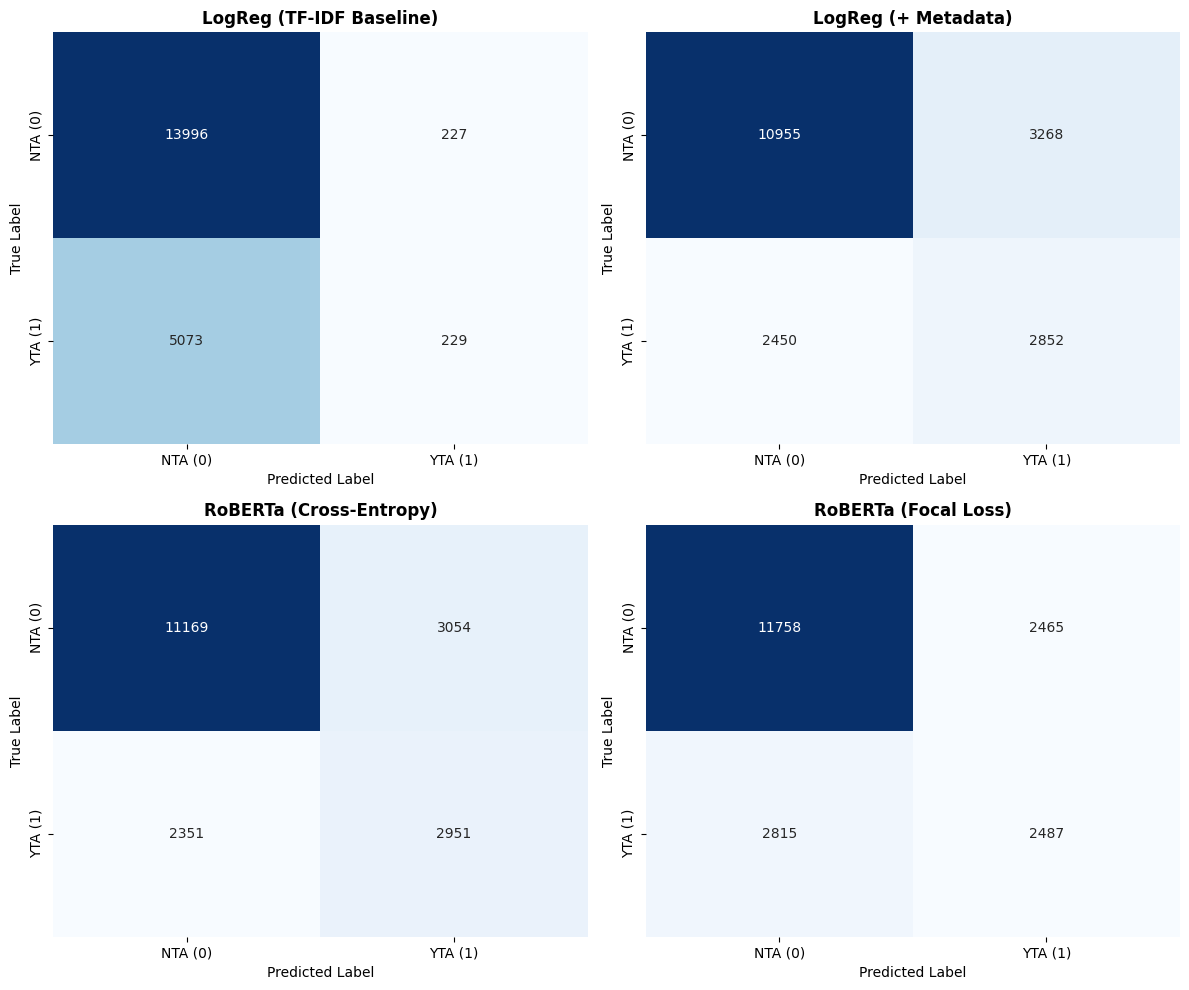

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

class_names = ["NTA (0)", "YTA (1)"]

for idx, (model_name, pred_col) in enumerate(model_cols.items()):
    y_pred = results_df[pred_col]
    cm = confusion_matrix(y_true, y_pred)
    
    # Text output
    print(f"=== Confusion Matrix: {model_name} ===")
    cm_df = pd.DataFrame(cm, index=["True NTA (0)", "True YTA (1)"], columns=["Pred NTA (0)", "Pred YTA (1)"])
    print(cm_df)
    print("-" * 45)
    
    # Heatmap visual
    sns.heatmap(
        cm, 
        annot=True, 
        fmt="d", 
        cmap="Blues", 
        cbar=False,
        xticklabels=class_names, 
        yticklabels=class_names,
        ax=axes[idx]
    )
    axes[idx].set_title(model_name, fontsize=12, fontweight='bold')
    axes[idx].set_xlabel("Predicted Label")
    axes[idx].set_ylabel("True Label")

plt.tight_layout()
plt.show()

The baseline logistic regression model seems to blanket predict most labels to be NTA, which makes sense with the class imbalance and gives high accuracy but low Macro F1. Giving the model access to metadata such as number of comments, score and whether it was edited increases performance over the baseline by a significant margin (0.46 vs 0.65 F1), suggesting that these values have some sort of predictive power. Fine-tuning LLMs like Roberta on just the text performs slightly better too (with not much discernible difference between the loss functions), which is expected due to the model's innate knowledge of social norms and tone of voice.

## Which metadata features have greatest predictive power:

Total Model Features: 3020
Text Features: 3000 | Metadata Features: 20

=== Top Metadata Features by Predictive Power ===


,feature,coef,abs_coef
0,comments_log,1.403907,1.403907
1,score_log,-1.331933,1.331933
2,title_char_len,0.304011,0.304011
3,is_edited,0.284858,0.284858
4,i_pronouns,-0.195279,0.195279
5,title_word_count,-0.189542,0.189542
6,hour_of_day,-0.120959,0.120959
7,body_char_len,0.094496,0.094496
8,body_word_count,0.080423,0.080423
9,vader_neu,-0.076062,0.076062


/var/folders/l1/86nzlvlj3313vn4h__34jl100000gn/T/ipykernel_85320/404808701.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


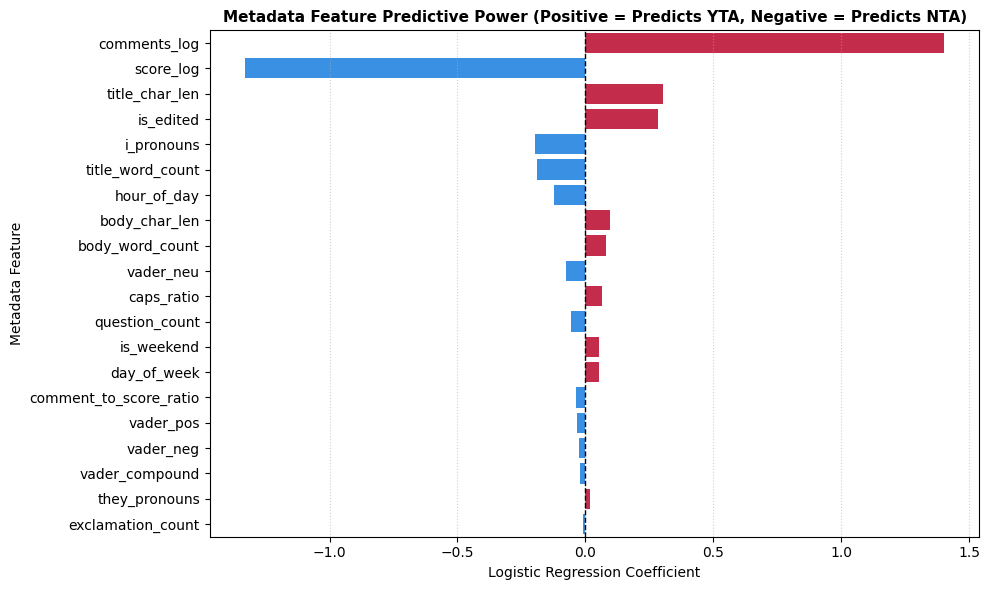

In [25]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load model bundle
bundle_path = "models/logreg_metadata_baseline.joblib"
bundle = joblib.load(bundle_path)

preprocessor = bundle["preprocessor"]
model = bundle["model"]

# 2. Extract TF-IDF feature names
if hasattr(preprocessor, "vectorizer") and hasattr(preprocessor.vectorizer, "get_feature_names_out"):
    text_feature_names = list(preprocessor.vectorizer.get_feature_names_out())
elif hasattr(preprocessor, "tfidf") and hasattr(preprocessor.tfidf, "get_feature_names_out"):
    text_feature_names = list(preprocessor.tfidf.get_feature_names_out())
else:
    # Fallback to standard tfidf attribute
    text_feature_names = [f"tfidf_{i}" for i in range(model.coef_.shape[1] - 20)]

# 3. Dynamically extract metadata feature names using a dummy row
dummy_df = pd.DataFrame([{
    'title': 'Sample title',
    'body': 'Sample body text',
    'clean_full_text': 'sample title sample body text',
    'score': 10,
    'num_comments': 5,
    'edited': False,
    'timestamp': 1600000000
}])

sample_meta_df = preprocessor.extract_metadata_features(dummy_df)
meta_feature_names = list(sample_meta_df.columns)

# 4. Combine all feature names
all_feature_names = text_feature_names + meta_feature_names
importances = model.coef_[0]

# Verify matching lengths
print(f"Total Model Features: {len(importances)}")
print(f"Text Features: {len(text_feature_names)} | Metadata Features: {len(meta_feature_names)}")

# 5. Build DataFrame for Metadata ONLY
# Grab the last N coefficients corresponding to the metadata features
meta_coefs = importances[-len(meta_feature_names):]

metadata_features = pd.DataFrame({
    'feature': meta_feature_names,
    'coef': meta_coefs,
    'abs_coef': np.abs(meta_coefs)
}).sort_values(by='abs_coef', ascending=False).reset_index(drop=True)

# 6. Display Table
print("\n=== Top Metadata Features by Predictive Power ===")
display(metadata_features)

# 7. Plot Bar Chart
plt.figure(figsize=(10, 6))
colors = ['crimson' if val > 0 else 'dodgerblue' for val in metadata_features['coef']]

sns.barplot(
    data=metadata_features,
    x='coef',
    y='feature',
    palette=colors
)

plt.title("Metadata Feature Predictive Power (Positive = Predicts YTA, Negative = Predicts NTA)", fontsize=11, fontweight='bold')
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Metadata Feature")
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [34]:
import joblib
import pandas as pd
import numpy as np
import statsmodels.api as sm

# 1. Load data and model bundle
results_df = pd.read_csv("models/error_analysis_results.csv")
bundle = joblib.load("models/logreg_metadata_baseline.joblib")
preprocessor = bundle["preprocessor"]

# 2. Use the preprocessor's native cleaning method
clean_df = preprocessor.clean_data(results_df)

# 3. Extract the raw metadata features
X_meta_raw = preprocessor.extract_metadata_features(clean_df)
meta_feature_names = list(X_meta_raw.columns)

# 4. Standardize using the ALREADY FITTED scaler from training
X_meta_scaled = preprocessor.scaler.transform(X_meta_raw)
X_meta_scaled = np.nan_to_num(X_meta_scaled) # Safety catch for zero-variance

# Convert to DataFrame so statsmodels respects our feature names
X_meta_df = pd.DataFrame(X_meta_scaled, columns=meta_feature_names, index=clean_df.index)
y = clean_df['is_asshole'].values

# =========================================================================
# 5. STATISTICAL SIGNIFICANCE (p-values & Confidence Intervals)
# =========================================================================
print("Fitting Logit model for statistical significance...")
X_with_const = sm.add_constant(X_meta_df)
logit_model = sm.Logit(y, X_with_const).fit(disp=False)

# Extract summary metrics safely using explicit pandas index lookups
conf_ints = logit_model.conf_int()
stats_df = pd.DataFrame({
    'Feature': meta_feature_names,
    'Coef': logit_model.params[meta_feature_names].values,
    'Std Error': logit_model.bse[meta_feature_names].values,
    'z-score': logit_model.tvalues[meta_feature_names].values,
    'p-value': logit_model.pvalues[meta_feature_names].values,
    'CI 2.5%': conf_ints.loc[meta_feature_names, 0].values,
    'CI 97.5%': conf_ints.loc[meta_feature_names, 1].values
})

# =========================================================================
# 6. POINT-BISERIAL CORRELATION
# =========================================================================
# Calculate direct correlation between each unscaled feature and the target
correlations = [X_meta_raw[col].corr(clean_df['is_asshole']) for col in meta_feature_names]
stats_df['Raw Target Correlation'] = correlations

# Format and sort by absolute z-score (statistical strength)
stats_df['Is Significant (p < 0.05)'] = stats_df['p-value'] < 0.05
stats_df['abs_z'] = np.abs(stats_df['z-score'])
summary_table = stats_df.sort_values(by='abs_z', ascending=False).drop(columns=['abs_z']).reset_index(drop=True)

print("\n=== Metadata Statistical Significance Summary ===")
display(summary_table.round(4))

Fitting Logit model for statistical significance...

=== Metadata Statistical Significance Summary ===


,Feature,Coef,Std Error,z-score,p-value,CI 2.5%,CI 97.5%,Raw Target Correlation,Is Significant (p < 0.05)
0,comments_log,1.1773,0.0709,16.6136,0.0000,1.0384,1.3162,0.1423,True
1,score_log,-1.0678,0.0803,-13.3054,0.0000,-1.2251,-0.9105,-0.0184,True
2,is_edited,0.3121,0.0386,8.0824,0.0000,0.2364,0.3878,0.0924,True
3,i_pronouns,-0.2602,0.0408,-6.3809,0.0000,-0.3402,-0.1803,-0.0447,True
4,caps_ratio,0.0573,0.0170,3.3624,0.0008,0.0239,0.0907,0.0374,True
5,comment_to_score_ratio,0.1098,0.0363,3.0251,0.0025,0.0387,0.1810,0.2680,True
6,title_char_len,0.2203,0.0730,3.0157,0.0026,0.0771,0.3634,0.0389,True
7,question_count,-0.0622,0.0262,-2.3718,0.0177,-0.1136,-0.0108,-0.0113,True
8,title_word_count,-0.1358,0.0651,-2.0868,0.0369,-0.2633,-0.0083,0.0333,True
9,vader_neu,-4.4491,2.7858,-1.5971,0.1103,-9.9091,1.0109,-0.0241,False


A naive analysis of the coefficients and significance values are quite illuminating. First off, the number of comments and the score of the post are both very strong signals for our model. If the number of comments is high (corresponding to a highly controversial/anger inducing post), it is likely a YTA.taking On the other hand, a high score seems to be predictive of a "NTA" label. Perhaps posts are upvoted more if the user is misunderstood but ultimately in the right. 

Other interesting findings: If a post has been edited, it is likely an "Asshole". This makes sense as well, as we may see users coming back to either defend their story or to apologize. Usage of the word "I" also coincides with more "NTA" posts. Users that speak in the first-person may be seen as taking more accountability, or just take more time explaining their thought process, both of which could garner sympathy with Redditors. The structure of the title also matters: Longer titles (character-wise) push towards YTA, and this is even more pronounced if the words are longer but fewer. 

## Raw Correlations:

In [36]:
# 1. Temporarily align the generated metadata features with the target label
X_meta_with_target = X_meta_raw.copy()
X_meta_with_target['is_asshole'] = clean_df['is_asshole'].values

# 2. Compute correlation matrix and extract just the 'is_asshole' column
# Drop the self-correlation of 'is_asshole' to 'is_asshole' (which is always 1.0)
correlations = X_meta_with_target.corr()['is_asshole'].drop('is_asshole')

# 3. Build the summary dataframe
corr_df = pd.DataFrame({
    'feature': correlations.index,
    'biserial_correlation': correlations.values,
    'abs_corr': np.abs(correlations.values)
}).sort_values(by='abs_corr', ascending=False).reset_index(drop=True)

display(corr_df)

,feature,biserial_correlation,abs_corr
0,comment_to_score_ratio,0.267951,0.267951
1,comments_log,0.142322,0.142322
2,is_edited,0.092406,0.092406
3,i_pronouns,-0.044701,0.044701
4,title_char_len,0.038864,0.038864
5,vader_pos,0.038193,0.038193
6,caps_ratio,0.037362,0.037362
7,title_word_count,0.033280,0.033280
8,body_word_count,-0.027132,0.027132
9,body_char_len,-0.025721,0.025721


Purely from a univariate correlation perspective, the greatest predictor seems to be the comment_to_score_ratio (+0.268). This corresponds with a social media phenomenon called getting "ratioed", where a post has high engagement (comments) but low upvotes. This differs from our model due to multicollinearity. The logistic regression model effectively recreated the signal from comment_to_score_ratio using purely the upvotes and the comment counts. The rest of the table agrees with our logistic regression model. Edited posts are strongly YTA, while using I pronouns will lean the court of public opinion the other way.

## Are any words/phrases highly predictive?

Loading model bundle from 'models/logreg_tfidf_baseline.joblib'...
Dimension mismatch! Features: 2020, Coefs: 2011
=== Top 20 YTA (Asshole) Words/Phrases ===


,feature,coef
0,edit,3.025435
1,throw,1.716217
2,secret,1.496508
3,gf,1.450834
4,coffee,1.426973
5,anyways,1.350518
6,looked,1.347352
7,didn want,1.302604
8,attention,1.302573
9,laugh,1.290379



=== Top 20 NTA (Not the Asshole) Words/Phrases ===


,feature,coef
0,mom,-1.493503
1,family,-1.452885
2,wanting,-1.449393
3,keeps,-1.419534
4,brother,-1.417980
5,upset,-1.389004
6,dropped,-1.307084
7,putting,-1.299924
8,bringing,-1.274557
9,rent,-1.270908


/var/folders/l1/86nzlvlj3313vn4h__34jl100000gn/T/ipykernel_85320/2792905207.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


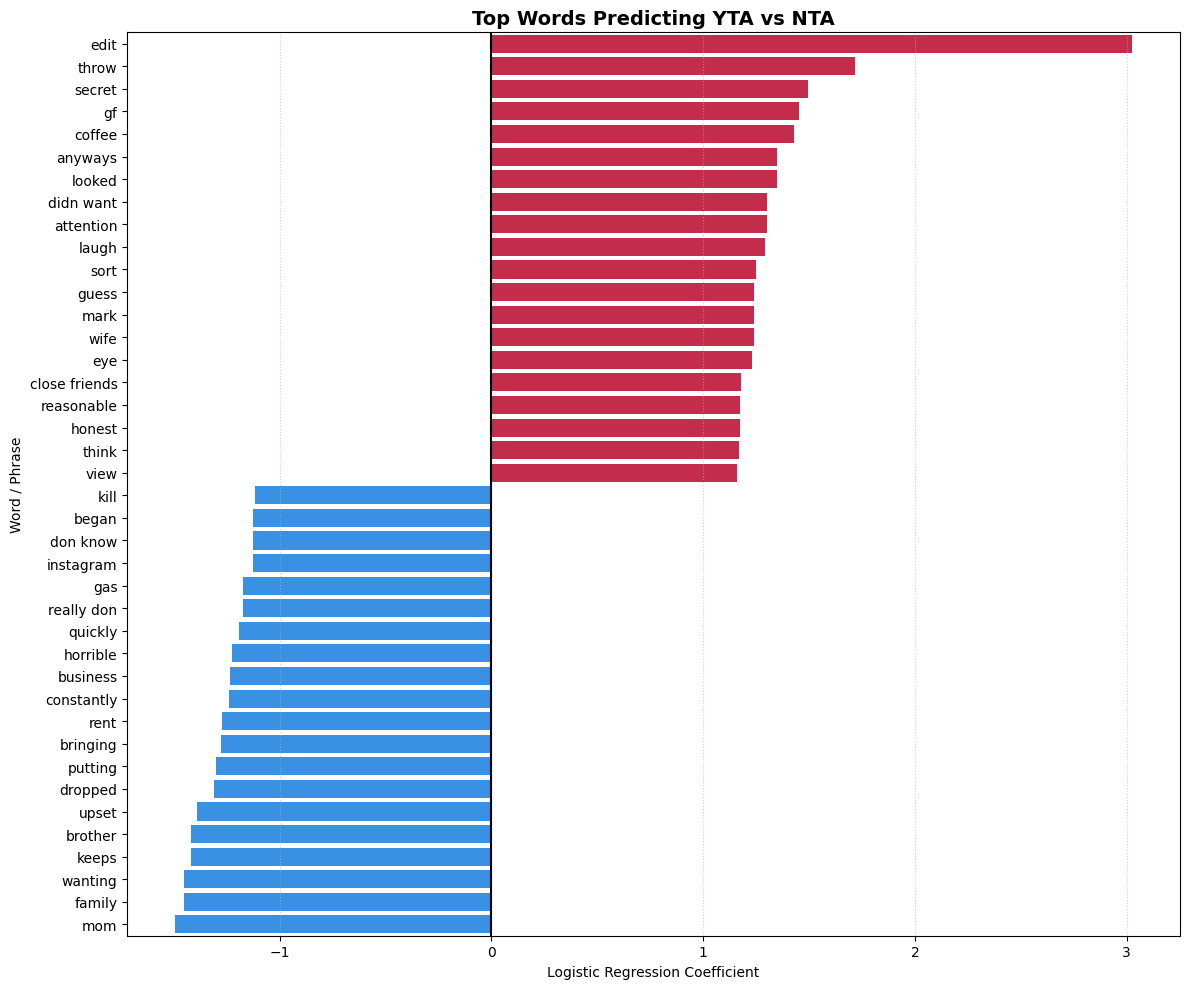

In [38]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the Model Bundle
bundle_path = "models/logreg_tfidf_baseline.joblib"
print(f"Loading model bundle from '{bundle_path}'...")
bundle = joblib.load(bundle_path)

# Extract preprocessor and model
preprocessor = bundle.get("preprocessor") or bundle.get("vectorizer")
model = bundle["model"]

# 2. Extract Text Features from the INTERNAL Vectorizer
if hasattr(preprocessor.vectorizer, "get_feature_names_out"):
    text_features = list(preprocessor.vectorizer.get_feature_names_out())
else:
    text_features = list(preprocessor.vectorizer.get_feature_names())

# 3. Define the Metadata Features 
# (Based on the exact order they are engineered in extract_metadata_features)
metadata_features = [
    'score_log', 'comments_log', 'comment_to_score_ratio', 'is_edited',
    'hour_of_day', 'day_of_week', 'is_weekend', 'title_char_len', 
    'title_word_count', 'body_char_len', 'body_word_count', 'caps_ratio', 
    'exclamation_count', 'question_count', 'i_pronouns', 'they_pronouns',
    'vader_neg', 'vader_neu', 'vader_pos', 'vader_compound'
]

# Combine to match the exact shape of X (text matrix + metadata matrix)
all_feature_names = text_features + metadata_features

# 4. Get Model Coefficients
importances = model.coef_[0]

# Quick dimension check
if len(all_feature_names) != len(importances):
    print(f"Dimension mismatch! Features: {len(all_feature_names)}, Coefs: {len(importances)}")
    min_len = min(len(all_feature_names), len(importances))
    all_feature_names = all_feature_names[:min_len]
    importances = importances[:min_len]

# 5. Create the DataFrame
vocab_df = pd.DataFrame({
    'feature': all_feature_names,
    'coef': importances
})

# Filter out the metadata features so we ONLY look at words/phrases
text_only_df = vocab_df[~vocab_df['feature'].isin(metadata_features)].copy()

# 6. Extract Top YTA and NTA Words
top_yta = text_only_df.sort_values(by='coef', ascending=False).head(20)
top_nta = text_only_df.sort_values(by='coef', ascending=True).head(20)

# Combine for visualization
top_words = pd.concat([top_yta, top_nta]).sort_values(by='coef', ascending=False)

# 7. Display Results
print("=== Top 20 YTA (Asshole) Words/Phrases ===")
display(top_yta.reset_index(drop=True))

print("\n=== Top 20 NTA (Not the Asshole) Words/Phrases ===")
display(top_nta.reset_index(drop=True))

# 8. Plotting
plt.figure(figsize=(12, 10))
colors = ['crimson' if c > 0 else 'dodgerblue' for c in top_words['coef']]

sns.barplot(
    data=top_words,
    x='coef',
    y='feature',
    palette=colors
)

plt.title("Top Words Predicting YTA vs NTA", fontsize=14, fontweight='bold')
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Word / Phrase")
plt.axvline(0, color='black', linestyle='-', linewidth=1.5)
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

Again, a naive look under the hood of the model yields quite interesting results. For the words/phrases which have high positive coefficients (YTA), we see that "edit" is an important signal in a YTA classification. Other words also make sense, such as aggressive words like "throw" or words that "toe-the-line" like "anyways", "guess", "didnt want", "think" or "reasonable". Interestingly, stories that talk about "gf"s or "close friends" also rank highly. This could indicate that people treat their significant others and close friends worse, or that audiences are less sympathetic when these parties are involved.

Let's look at the list of words which predict an NTA classification. Building on the previous findings, words like "mom", "family" and "brother" rank highly. Additionally, words like "upset", "horrible" or "wanting" seem to indicate some sort of remorse or accountability of the situation. Furthermore, the "environment" where the story occurs: "business", "rent, "gas" or "instagram" belie a common societal understanding of tough environments that are prone to argument or conflict. The most surprising appearance on the list: "kill". Obviously, any post that features the word "kill" in a genuine way should almost certainly be labeled as "YTA", indicating that either many of these genuine posts are getting filtered or that users themselves are aware of the heavy connotation of the word. In fact, the very opposite may be true where only users who know they are in the right would possibly use the word in any context.

## Chi-Squared Test for Independence

In [40]:
import joblib
import pandas as pd
import numpy as np
from sklearn.feature_selection import chi2

# 1. Load Data and Bundle
results_df = pd.read_csv("models/error_analysis_results.csv")
bundle = joblib.load("models/logreg_tfidf_baseline.joblib")
preprocessor = bundle.get("preprocessor") or bundle.get("vectorizer")

# 2. Manually clean and combine text
for col in ['title', 'body']:
    if col in results_df.columns:
        results_df[col] = results_df[col].fillna("").astype(str)

# Combine title and body into a single string for the vectorizer
results_df['clean_full_text'] = results_df['title'] + " " + results_df['body']

# 3. Extract ONLY the text TF-IDF matrix using the internal vectorizer
X_text = preprocessor.vectorizer.transform(results_df['clean_full_text'])
y = results_df['is_asshole'].values

# 4. Get text vocabulary
if hasattr(preprocessor.vectorizer, "get_feature_names_out"):
    text_features = list(preprocessor.vectorizer.get_feature_names_out())
else:
    text_features = list(preprocessor.vectorizer.get_feature_names())

# 5. Run Chi-Squared Test
print("Running Chi-Squared test on TF-IDF vocabulary...")
chi2_scores, p_values = chi2(X_text, y)

# 6. Build Results DataFrame
chi2_df = pd.DataFrame({
    'word': text_features,
    'chi2_stat': chi2_scores,
    'p_value': p_values
})

# Add a boolean column for standard significance (p < 0.05)
chi2_df['is_significant'] = chi2_df['p_value'] < 0.05

# Sort by lowest p-value (most significant) and then highest Chi2 stat
chi2_df = chi2_df.sort_values(by=['p_value', 'chi2_stat'], ascending=[True, False]).reset_index(drop=True)

# 7. Display the true statistical signals
print(f"\nTotal words in vocabulary: {len(text_features)}")
print(f"Words statistically significant (p < 0.05): {chi2_df['is_significant'].sum()}")

print("\n=== Top 20 Most Statistically Significant Words ===")
display(chi2_df.head(20))

Running Chi-Squared test on TF-IDF vocabulary...

Total words in vocabulary: 2000
Words statistically significant (p < 0.05): 11

=== Top 20 Most Statistically Significant Words ===


,word,chi2_stat,p_value,is_significant
0,edit,9.248347,0.002357,True
1,mom,8.820301,0.002979,True
2,wife,6.771407,0.009263,True
3,dad,6.310582,0.012002,True
4,mother,5.845080,0.015621,True
5,mum,5.516045,0.018843,True
6,girl,5.073847,0.024289,True
7,aita wanting,4.714024,0.029918,True
8,x200b edit,4.656430,0.030937,True
9,family,4.359379,0.036806,True


In [41]:
# 1. Map the model's coefficients to our Chi2 dataframe
# (Aligning text feature names with model coefficients)
coef_dict = dict(zip(text_features, model.coef_[0][:len(text_features)]))

chi2_df['coef'] = chi2_df['word'].map(coef_dict)

# 2. Assign human-readable direction based on coefficient sign
chi2_df['direction'] = chi2_df['coef'].apply(lambda x: 'YTA (Asshole)' if x > 0 else 'NTA (Not Asshole)')

# 3. View the top significant words WITH their direction
significant_words = chi2_df[chi2_df['is_significant']].sort_values(
    by='chi2_stat', ascending=False
)

display(significant_words[['word', 'chi2_stat', 'p_value', 'coef', 'direction']])

,word,chi2_stat,p_value,coef,direction
0,edit,9.248347,0.002357,3.025435,YTA (Asshole)
1,mom,8.820301,0.002979,-1.493503,NTA (Not Asshole)
2,wife,6.771407,0.009263,1.237908,YTA (Asshole)
3,dad,6.310582,0.012002,-0.536977,NTA (Not Asshole)
4,mother,5.845080,0.015621,-0.953588,NTA (Not Asshole)
5,mum,5.516045,0.018843,-0.009600,NTA (Not Asshole)
6,girl,5.073847,0.024289,0.421254,YTA (Asshole)
7,aita wanting,4.714024,0.029918,-0.356605,NTA (Not Asshole)
8,x200b edit,4.656430,0.030937,0.744776,YTA (Asshole)
9,family,4.359379,0.036806,-1.452885,NTA (Not Asshole)


Once more, an edited post is a pretty clear sign that a post is "YTA". Additionally the big finding is that most words simply don't matter at all. Only 11 words are statistically significant, and this helps explain why the baseline logistic regression model trained only on tfidf vectors basically resorted to predicting "NTA" for every post. Combining the results of the chi-squared test with our model: 

Familial relationships are strongly "NTA". Posts involving the nuclear family may trigger community biases such as "toxic parents" and "annoying siblings". Comparatively, mentions of a "wife" or "girl" sways readers the other way. Maybe men treat their significant others worse, or Redditors side with women more than men. An interesting follow-up could be looking at the gender of posters as well as the general demographic breakdown of r/AITA perusers.

Finally, it looks like a common phenomenon is the "Thought Crime". When a user says "AITA wanting" (usually in titles like "AITA for wanting to..."), it typically signals a hypothetical conflict rather than an action that has already caused harm. The community tends to judge "wanting" to do something much more leniently (NTA) than actually doing it.

# Analyzing our Finetuned LLM

## Specifically, look at the body's of posts that were misclassified by roberta to see what Language Models perform worse on

In [20]:
hard_errors = results_df[
    (results_df['is_asshole'] != results_df['pred_roberta_ce']) & 
    (results_df['is_asshole'] != results_df['pred_roberta_focal'])
]

with pd.option_context('display.max_colwidth', None):
    display(hard_errors[['title', 'body', 'is_asshole', 'pred_roberta_ce', 'pred_roberta_focal']].head(10))

,title,body,is_asshole,pred_roberta_ce,pred_roberta_focal
9,AITA for taking playfighting with kids too seriously?,"This happened at my nephews 3rd birthday party. I usually play fight with my nephew just because it's funny and he enjoys it when I let him win and laughs at my dramatics.\n\nSo I was at his 3rd birthday party and I was just walking around socialising etc when he ran up to me with a toy in the shape of a gun and fired it at me. I thought ""why not"" and dropped to my knees and let out a big ""Arrrgghhh! Why did you do this?!"". Then I crawled towards him as if I was gonna get my revenge which prompted him to jump on me and attack me. The normal stuff. The adults in the room were laughing, he was having fun, all is well. Then some of the other kids joined in and by then I have 4 children on my back while I lay on the floor begging for mercy. Then my nephew gets up nd shoots me again so I start spazzing out and growling like I'm dying. Kinda like [what this guy is doing](https://youtu.be/LA0zo9il60Y?t=40) (at 40secs).\n\nMaybe I took it too far, because every single one of those children freaked out and started crying and screaming. One of the kids jumped off and tried to run but he fell on something and the way he fell caused him to get carpet burn on his knee. His mother was livid saying I played too rough. To me it sounded like she was implying I playfully threw him and he got injured, but in actuality, he fell because he ran on his own accord. I tried to explain this but it appeared like I was arguing with her because I was trying to raise my voice over the screaming and loud music.\n\nMultiple adults told me I should just leave since I ruined the party and even my cousin (nephew's mother) said I should just go. His dad didn't care too much cause he knows I wasn't trying to do anything bad, so I just left since I clearly overstayed my welcome.\n\nI tried to text my cousin to apologise but she isn't getting back to me. Her husband told me it's not really a big deal, but I really don't know if I am the asshole or this whole thing was blown out of proportion.",0,1,1
10,AITA for being annoyed about my best friends out of country wedding?,"Ok I’ve gone back and forth with AITA or not.\n\nDecember 2018 my friend J began talking about plans for a destination wedding out of the country. I politely try and tell her (more than once) that I didn’t think it was a good idea because of where our group of friends are at in our lives.\n\nApril 2019 they officially get engaged. \n\nBridesmaids: early 20’s, childhood friends, all of us in one Midwest state including brides family; except bride and 1 bridesmaid.\n\nBridesmaid N: In fall 2018 moved out west to be with her mom because her heroin addiction was close to killing her.\n\nBridesmaid L: Lives at home helping support her family. No car, hard to hold a job. Unstable.\n\nMyself: Has a small child. I also got married 2 months ago at a courthouse. We decided against a real wedding because we’re buying our 1st home this Spring.\n\nThe other 2 bridesmaids are pretty stable.\n\nBride lives on east coast with fiancé.\nFiancé family all live by destination wedding location. (Fiancé is almost 10 years older and has a real career).\n\nBasically, bride and I got into argument this morning that stemmed from the bridesmaid dresses. I’ve been trying to get J to pick a color for months now. J finally picks color, says they just need to be long and flow. I order 3 sample sizes and show her (2 I had approval on already) the 3rd she says doesn’t follow her guidelines. She says she pictured an A line. Ok that’s totally fine. What’s not, is that the wedding is ~9 months away and I had to force her to pick a color and not being specific enough about her vision.\n\nWe also had issues with our reservations at the all inclusive hotel. I told the bride twice we would be booking within the week because of a deal that I found. Resort didn’t pull money from my account until 3 weeks later after I conta

Reading through these, it is hard to find a true discernible pattern amongst the various posts. However, a few ideas come to mind. First off, these LLMs seem to have a hard time discerning between intention and impact. In the first post, the poster attempts to play along but accidentally ends up causing harm, while in post #4, the user is called out for "shouting" even though they are defending their friends. It may be hard for the model to weigh the exact impact of a person's actions vs their actual harmless intention.

Another enduring theme seems to be a difficulty with social nuance or cultural norms. The ideas of breastfeeding, or not being able to afford going to a destination wedding, or the idea of "driving etiquette" are all ideas that there is consensus on but may not be explicitly written down. Additionally, some of these topics may have conflicting information, such as strong legal rights/support for public breastfeeding vs. internet complaints about workplace boundary violations, which may give the model difficulty in balancing legal rights vs social faux pas.

Finally, some of these posts are quite long and contain edits/TLDRs by the user. Since I used a preprocessing technique on the dataset so that only the starts and ends of each post are kept (to give the model as much important context as possible), this could lead to possible errors. For example, in the story with the breastfeeding, there contains an edit where the user says "I've agreed with those who have opposed me and I've come to terms that i was in the wrong... and yet." Edits, TLDRs or self-corrections can all give biased accounts of the situation and can mess with the temporal context of the model. I can't be sure if it is evaluating the actual story or the updated perspective of the user.

=== Word Count Summary by Error Type ===


,count,mean,median,max
error_type,,,,
True Positive (Correct YTA),2951.0,334.2,309.0,2557.0
"False Positive (Model YTA, Truth NTA)",3054.0,342.1,304.0,3163.0
"False Negative (Model NTA, Truth YTA)",2351.0,352.6,324.0,2522.0
True Negative (Correct NTA),11169.0,356.3,331.0,2720.0


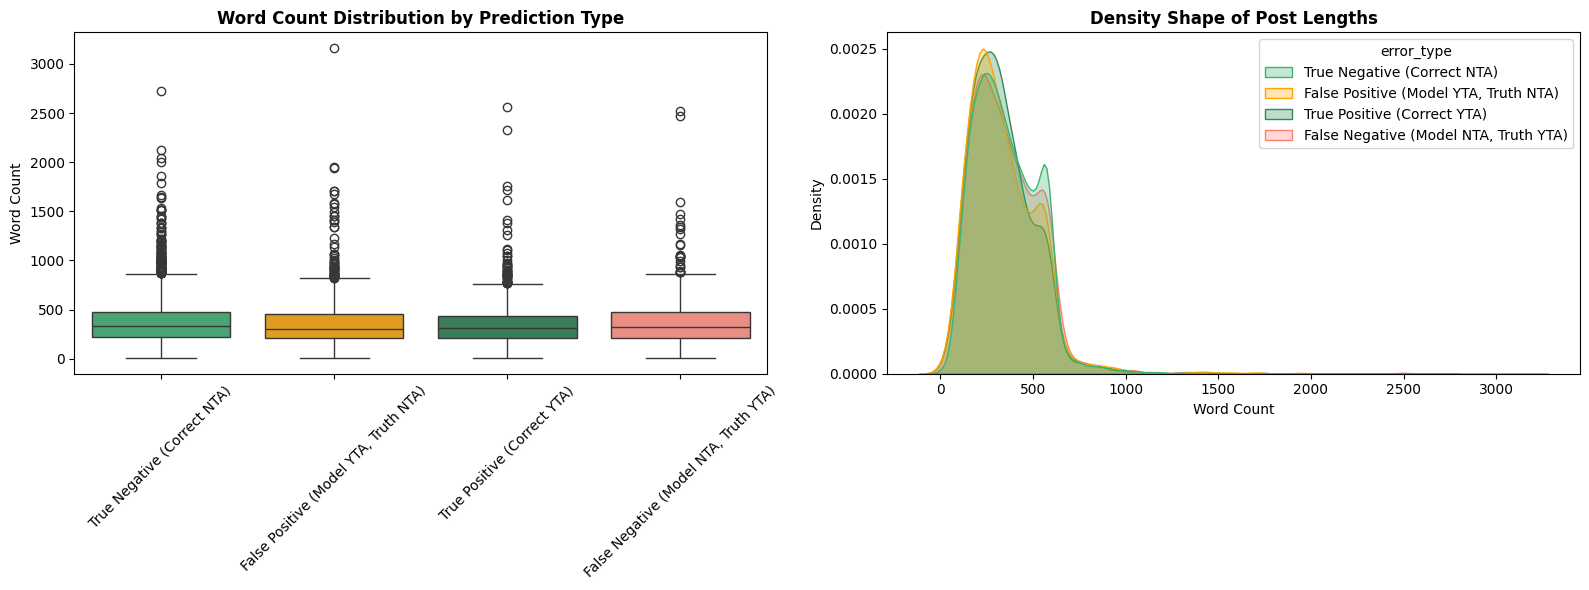

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
results_df = pd.read_csv("models/error_analysis_results.csv")

# Clean text
for col in ['title', 'body']:
    if col in results_df.columns:
        results_df[col] = results_df[col].fillna("").astype(str)

results_df['clean_full_text'] = results_df['title'] + " " + results_df['body']

# 2. Calculate Length
results_df['word_count'] = results_df['clean_full_text'].apply(lambda x: len(x.split()))

# =========================================================================
# 3. DEFINE ERROR TYPES
# =========================================================================
prediction_col = 'pred_roberta_ce' 

if prediction_col not in results_df.columns:
    raise KeyError(f"Please update `prediction_col` to match your LLM's output column.")

# Categorize into the confusion matrix quadrants
conditions = [
    (results_df['is_asshole'] == 0) & (results_df[prediction_col] == 0), # True Negative
    (results_df['is_asshole'] == 1) & (results_df[prediction_col] == 1), # True Positive
    (results_df['is_asshole'] == 0) & (results_df[prediction_col] == 1), # False Positive
    (results_df['is_asshole'] == 1) & (results_df[prediction_col] == 0)  # False Negative
]

choices = [
    'True Negative (Correct NTA)',
    'True Positive (Correct YTA)',
    'False Positive (Model YTA, Truth NTA)',
    'False Negative (Model NTA, Truth YTA)'
]

results_df['error_type'] = np.select(conditions, choices, default='Unknown')

# Define a consistent color palette for the plots
palette = {
    'True Negative (Correct NTA)': 'mediumseagreen',
    'True Positive (Correct YTA)': 'seagreen',
    'False Positive (Model YTA, Truth NTA)': 'orange',
    'False Negative (Model NTA, Truth YTA)': 'salmon'
}

# 4. Statistical Summary
summary_stats = results_df.groupby('error_type')['word_count'].describe()[['count', 'mean', '50%', 'max']]
summary_stats.rename(columns={'50%': 'median'}, inplace=True)

print("=== Word Count Summary by Error Type ===")
display(summary_stats.round(1).sort_values(by='mean'))

# 5. Visualizations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot
sns.boxplot(
    data=results_df, 
    x='error_type', 
    y='word_count', 
    hue='error_type',
    palette=palette, 
    ax=ax1,
    legend=False
)
ax1.set_title("Word Count Distribution by Prediction Type", fontweight='bold')
ax1.set_ylabel("Word Count")
ax1.set_xlabel("")
ax1.tick_params(axis='x', rotation=45)

# KDE Density Plot
sns.kdeplot(
    data=results_df, 
    x='word_count', 
    hue='error_type', 
    fill=True, 
    alpha=0.3, # Slightly more transparent since we have 4 curves now
    common_norm=False, 
    palette=palette,
    ax=ax2
)
ax2.set_title("Density Shape of Post Lengths", fontweight='bold')
ax2.set_xlabel("Word Count")

plt.tight_layout()
plt.show()

The charts above tell us that there is basically no difference in the statistics of positives, negatives or false predictions. 

## Instead, let's set a threshold for where the model's context window likely breaks:

In [50]:
import pandas as pd
import numpy as np

# 1. Set model prediction column name
prediction_col = 'pred_roberta_ce'

# 2. Ensure text, word count, and error flags exist
for col in ['title', 'body']:
    if col in results_df.columns:
        results_df[col] = results_df[col].fillna("").astype(str)

results_df['clean_full_text'] = results_df['title'] + " " + results_df['body']
results_df['word_count'] = results_df['clean_full_text'].apply(lambda x: len(x.split()))

# Explicitly calculate error boolean
results_df['is_error'] = (results_df['is_asshole'] != results_df[prediction_col]).astype(int)

# 3. Define length buckets based on RoBERTa token limits
# (~350 words is roughly where 512 subword tokens truncate)
bins = [0, 150, 300, 450, np.inf]
labels = [
    'Short (<150w)', 
    'Medium (150-300w)', 
    'Long (300-450w)', 
    'Truncated Risk (>450w)'
]

results_df['length_bucket'] = pd.cut(results_df['word_count'], bins=bins, labels=labels)

# 4. Calculate Error Rate per bucket
bucket_analysis = results_df.groupby('length_bucket', observed=False).agg(
    total_posts=('is_error', 'count'),
    total_errors=('is_error', 'sum'),
    error_rate=('is_error', 'mean')
).reset_index()

bucket_analysis['error_rate_pct'] = (bucket_analysis['error_rate'] * 100).round(2)

print("=== Model Error Rate Across Post Length Buckets ===")
display(bucket_analysis[['length_bucket', 'total_posts', 'total_errors', 'error_rate_pct']])

=== Model Error Rate Across Post Length Buckets ===


,length_bucket,total_posts,total_errors,error_rate_pct
0,Short (<150w),2103,644,30.62
1,Medium (150-300w),6763,1925,28.46
2,Long (300-450w),5324,1405,26.39
3,Truncated Risk (>450w),5335,1431,26.82


Interesting, just looking at the raw counts in each bucket seems to indicate a reversal of my original hypothesis: shorter posts lead to model performance degradation. The model is starved of context and can not make an informed prediction, whereas even if some of a post gets cut off due to token limits and forced truncation, some context is better than none.

## Control for Class Imbalances in Buckets

In [51]:
import pandas as pd
import numpy as np

def compute_balanced_bucket_metrics(df, pred_col, target_col='is_asshole'):
    def calc_group(group):
        y_true = group[target_col]
        y_pred = group[pred_col]
        
        # Class distributions
        total = len(group)
        yta_count = (y_true == 1).sum()
        nta_count = (y_true == 0).sum()
        
        # Per-class errors
        fn_count = ((y_true == 1) & (y_pred == 0)).sum() # Missed YTA
        fp_count = ((y_true == 0) & (y_pred == 1)).sum() # False YTA
        
        # Rates (Handling division by zero safely)
        fnr = (fn_count / yta_count * 100) if yta_count > 0 else 0 # % of YTAs missed
        fpr = (fp_count / nta_count * 100) if nta_count > 0 else 0 # % of NTAs falsely accused
        
        # Balanced Error Rate
        balanced_error_rate = (fnr + fpr) / 2
        
        return pd.Series({
            'total_posts': total,
            'yta_share_pct': round((yta_count / total) * 100, 1),
            'fnr_missed_yta_pct': round(fnr, 2),
            'fpr_false_yta_pct': round(fpr, 2),
            'balanced_error_rate_pct': round(balanced_error_rate, 2)
        })

    return df.groupby('length_bucket', observed=False).apply(calc_group).reset_index()

# Run balanced evaluation
balanced_bucket_df = compute_balanced_bucket_metrics(results_df, pred_col='pred_roberta_ce')
display(balanced_bucket_df)

,length_bucket,total_posts,yta_share_pct,fnr_missed_yta_pct,fpr_false_yta_pct,balanced_error_rate_pct
0,Short (<150w),2103.0,29.7,42.88,25.44,34.16
1,Medium (150-300w),6763.0,27.5,42.62,23.08,32.85
2,Long (300-450w),5324.0,28.0,42.28,20.21,31.25
3,Truncated Risk (>450w),5335.0,24.8,49.77,19.25,34.51


Having controlled for class imbalance, a new narrative emerges: truncation does kill recall. The false negative rate on posts over 450 words spikes to 49.77, which means roberta is defaulting to predicting "NTA" (the majority class) on these longer posts. For short posts (under 150 words), the opposite is true. With a false positive rate (YTA) of 25.44, giving the model no context at all makes it much more likely to falsely accuse someone of being an asshole. 

## Does Focal Loss Help with This?

In [52]:
import pandas as pd
import numpy as np

def compute_balanced_bucket_metrics(df, pred_col, target_col='is_asshole'):
    def calc_group(group):
        y_true = group[target_col]
        y_pred = group[pred_col]
        
        # Class distributions
        total = len(group)
        yta_count = (y_true == 1).sum()
        nta_count = (y_true == 0).sum()
        
        # Per-class errors
        fn_count = ((y_true == 1) & (y_pred == 0)).sum() # Missed YTA
        fp_count = ((y_true == 0) & (y_pred == 1)).sum() # False YTA
        
        # Rates (Handling division by zero safely)
        fnr = (fn_count / yta_count * 100) if yta_count > 0 else 0 # % of YTAs missed
        fpr = (fp_count / nta_count * 100) if nta_count > 0 else 0 # % of NTAs falsely accused
        
        # Balanced Error Rate
        balanced_error_rate = (fnr + fpr) / 2
        
        return pd.Series({
            'total_posts': total,
            'yta_share_pct': round((yta_count / total) * 100, 1),
            'fnr_missed_yta_pct': round(fnr, 2),
            'fpr_false_yta_pct': round(fpr, 2),
            'balanced_error_rate_pct': round(balanced_error_rate, 2)
        })

    return df.groupby('length_bucket', observed=False).apply(calc_group).reset_index()

# Run balanced evaluation
balanced_bucket_df = compute_balanced_bucket_metrics(results_df, pred_col='pred_roberta_focal')
display(balanced_bucket_df)

,length_bucket,total_posts,yta_share_pct,fnr_missed_yta_pct,fpr_false_yta_pct,balanced_error_rate_pct
0,Short (<150w),2103.0,29.7,45.76,22.53,34.15
1,Medium (150-300w),6763.0,27.5,51.10,19.35,35.22
2,Long (300-450w),5324.0,28.0,52.68,16.20,34.44
3,Truncated Risk (>450w),5335.0,24.8,59.82,14.04,36.93


Using focal loss as the loss function also led to the same problem. In fact, it was a lot more conservative and exacerbated the false negative rate, whereas false positives dropped significantly. 

## Bimodal Predictions and Model Calibration

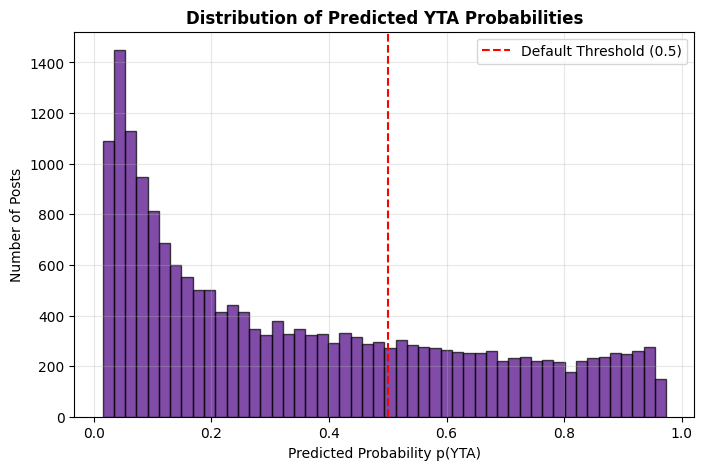

In [55]:
import matplotlib.pyplot as plt

# Extract predicted probabilities for YTA (Class 1)
probs_yta = results_df['prob_roberta_ce'] 

plt.figure(figsize=(8, 5))
plt.hist(probs_yta, bins=50, color='indigo', edgecolor='black', alpha=0.7)
plt.axvline(0.5, color='red', linestyle='--', label='Default Threshold (0.5)')
plt.title("Distribution of Predicted YTA Probabilities", fontweight='bold')
plt.xlabel("Predicted Probability p(YTA)")
plt.ylabel("Number of Posts")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

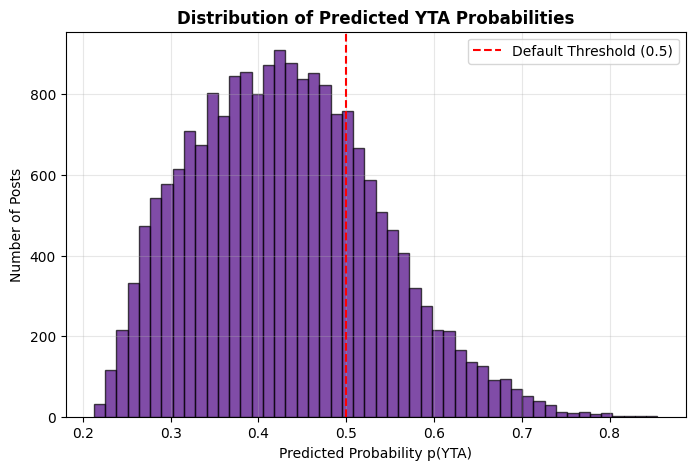

In [56]:
import matplotlib.pyplot as plt

# Extract predicted probabilities for YTA (Class 1)
probs_yta = results_df['prob_roberta_focal'] 

plt.figure(figsize=(8, 5))
plt.hist(probs_yta, bins=50, color='indigo', edgecolor='black', alpha=0.7)
plt.axvline(0.5, color='red', linestyle='--', label='Default Threshold (0.5)')
plt.title("Distribution of Predicted YTA Probabilities", fontweight='bold')
plt.xlabel("Predicted Probability p(YTA)")
plt.ylabel("Number of Posts")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

A direct comparison between Cross-Entropy and Focal Loss reveals stark differences in model calibration. When using Cross-Entropy Loss, the model maintained a healthy, full-spectrum probability distribution ($0.0$ to $1.0$). Its decision boundary remained stable at $0.50$ during Macro F1 optimization, serving as the far superior loss function. On the other hand, the model trained with Focal Loss caused severe probability compression, collapsing outputs into a narrow bell curve centered around $p \approx 0.43$. Because most predictions sat below $0.50$, the model became excessively hesitant to predict YTA, driving missed YTA verdicts on long posts up to 59.8% and rendering decision threshold tuning ineffective which is why a threshold of 0.5 was chosen.

Overall, this indicates that Cross Entropy Loss is the far better model.

# Topic Modeling

In [58]:
import os
import pandas as pd
from bertopic import BERTopic
from sklearn.metrics import f1_score

# Suppress the tokenizer parallelism warnings
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# 1. Initialize BERTopic 
print("Initializing BERTopic and generating embeddings...")
topic_model = BERTopic(embedding_model="all-MiniLM-L6-v2", calculate_probabilities=False)

# 2. Fit the model and extract topics (This may take a few minutes)
docs = results_df['clean_full_text'].tolist()
topics, _ = topic_model.fit_transform(docs)

# 3. Map topics back to your DataFrame
results_df['topic_id'] = topics

# Generate readable names for the clusters (Removed the invalid parameter)
topic_labels = topic_model.generate_topic_labels(nr_words=3, topic_prefix=True, separator="_")
topic_model.set_topic_labels(topic_labels)
results_df['topic_name'] = results_df['topic_id'].map(topic_model.custom_labels_)

# 4. View what BERTopic discovered
print("\n=== Discovered Topics Overview ===")
topic_info = topic_model.get_topic_info()
display(topic_info.head(10)) 

# =========================================================================
# 5. Evaluate Model Performance on the Discovered Topics
# =========================================================================
prediction_col = 'pred_roberta_ce' # Swap to your active prediction column

def compute_discovered_topic_metrics(df, pred_col, target_col='is_asshole'):
    def calc_group(group):
        y_true = group[target_col]
        y_pred = group[pred_col]
        
        total = len(group)
        yta_count = (y_true == 1).sum()
        nta_count = (y_true == 0).sum()
        
        macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
        
        fn_count = ((y_true == 1) & (y_pred == 0)).sum()
        fp_count = ((y_true == 0) & (y_pred == 1)).sum()
        
        fnr = (fn_count / yta_count * 100) if yta_count > 0 else 0
        fpr = (fp_count / nta_count * 100) if nta_count > 0 else 0
        balanced_error = (fnr + fpr) / 2
        
        return pd.Series({
            'total_posts': total,
            'yta_share_pct': round((yta_count / total) * 100, 1),
            'macro_f1': round(macro_f1, 3),
            'fnr_missed_yta_pct': round(fnr, 2),
            'fpr_false_yta_pct': round(fpr, 2),
            'balanced_error_rate_pct': round(balanced_error, 2)
        })

    return df.groupby('topic_name', observed=False).apply(calc_group).reset_index()

# Calculate and display the metrics
topic_metrics = compute_discovered_topic_metrics(results_df, pred_col=prediction_col)

# Filter out tiny micro-clusters (less than 100 posts) and sort by Macro F1
valid_topics = topic_metrics[topic_metrics['total_posts'] > 100]
valid_topics = valid_topics.sort_values(by='macro_f1', ascending=False)

print("\n=== Model Performance by BERTopic Clusters ===")
display(valid_topics.head(15))

/opt/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Initializing BERTopic and generating embeddings...


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

TypeError: BERTopic.generate_topic_labels() got an unexpected keyword argument 'word_length_multiplier'